# Scheduling simulator — exploration

Thin notebook layered on top of `shared/runner.py`, `shared/evaluation.py`, `shared/constants.py`, `shared/reporter.py`, and `shared/plots.py`.

In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))

from shared.constants import COMPARISON_METRICS
from shared.evaluation import pick_winners
from shared.runner import run_simulation
from shared.parser import parse_input
from shared.plots import plot_gantt, plot_metric_bars
from shared.reporter import print_comparison

workload = parse_input("inputs/workload.json")
workload


Workload(processes=(Process(pid='P1', arrival=0, priority=2, bursts=(5, 3, 3)), Process(pid='P2', arrival=1, priority=1, bursts=(4,)), Process(pid='P3', arrival=2, priority=3, bursts=(2, 2, 4)), Process(pid='P4', arrival=4, priority=2, bursts=(1,)), Process(pid='P5', arrival=4, priority=4, bursts=(3,)), Process(pid='P6', arrival=6, priority=1, bursts=(2, 1, 2)), Process(pid='P7', arrival=10, priority=2, bursts=(1,)), Process(pid='P8', arrival=11, priority=3, bursts=(2, 2, 2)), Process(pid='P9', arrival=12, priority=1, bursts=(6,)), Process(pid='P10', arrival=12, priority=4, bursts=(1, 3, 2)), Process(pid='P11', arrival=14, priority=2, bursts=(3, 1, 3)), Process(pid='P12', arrival=15, priority=3, bursts=(1,)), Process(pid='P13', arrival=16, priority=1, bursts=(2, 2, 2, 2, 1)), Process(pid='P14', arrival=18, priority=4, bursts=(4,)), Process(pid='P15', arrival=20, priority=2, bursts=(1, 3, 1)), Process(pid='P16', arrival=21, priority=5, bursts=(7,)), Process(pid='P17', arrival=22, priori

In [9]:
results, gantts, reports = run_simulation(workload)

In [10]:
print_comparison(reports, pick_winners(reports))

Comparison
algorithm         avg_turnaround  avg_waiting  avg_response  cpu_utilization
----------------  --------------  -----------  ------------  ---------------
FCFS              71.2222         65.7778      37.5926       0.7143         
SJF               58.2593         52.8148      41.3704       0.7143         
SJF (preemptive)  58.1481         52.7037      40.3333       0.7051         
Priority          65.0370         59.5926      52.7037       0.7097         
Round Robin       77.6296         72.1852      35.7778       0.6962         

Winner per metric
  avg_turnaround: SJF (preemptive)
  avg_waiting: SJF (preemptive)
  avg_response: Round Robin
  cpu_utilization: FCFS


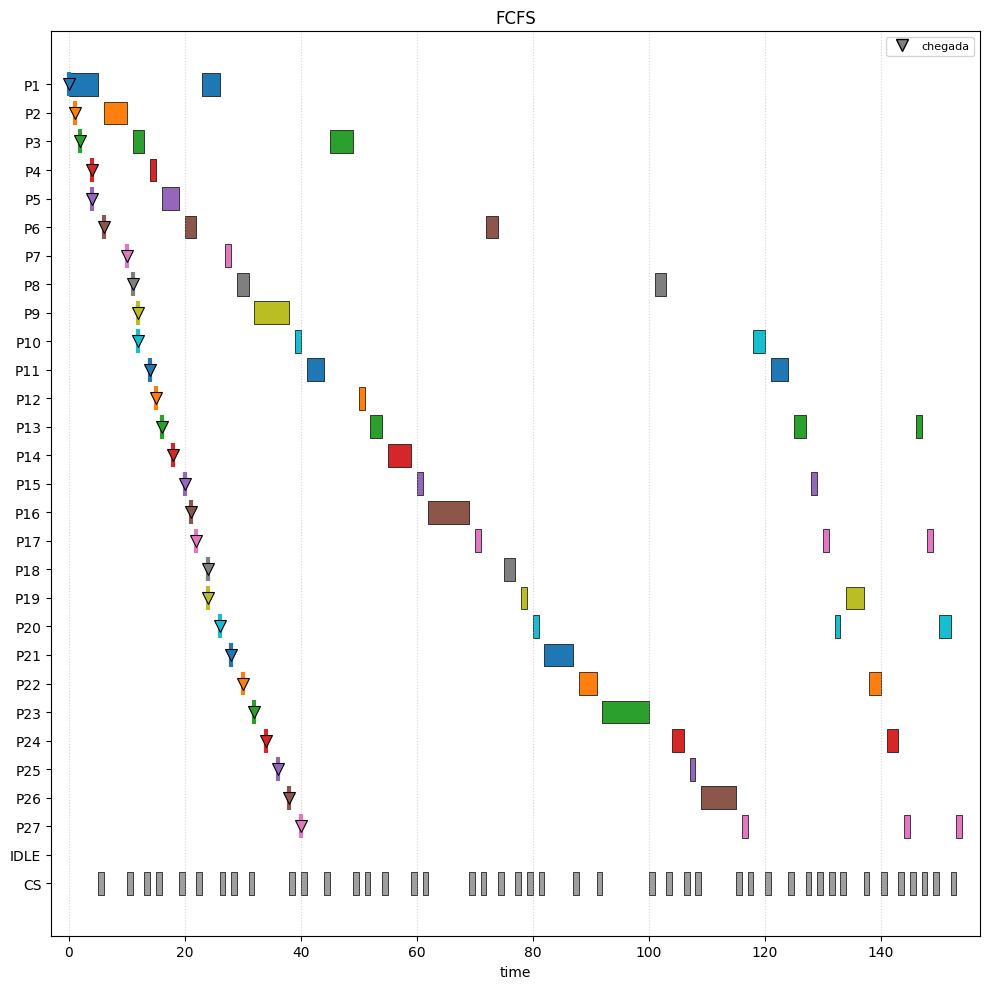

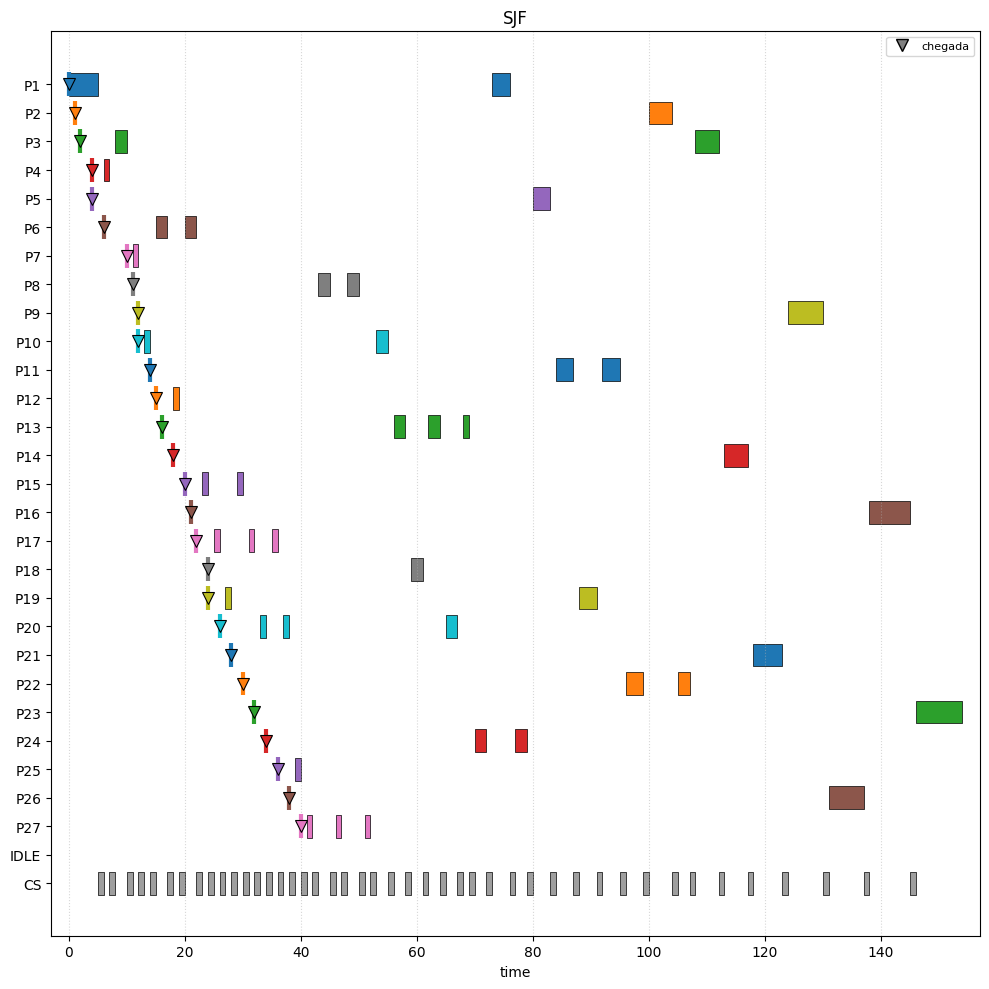

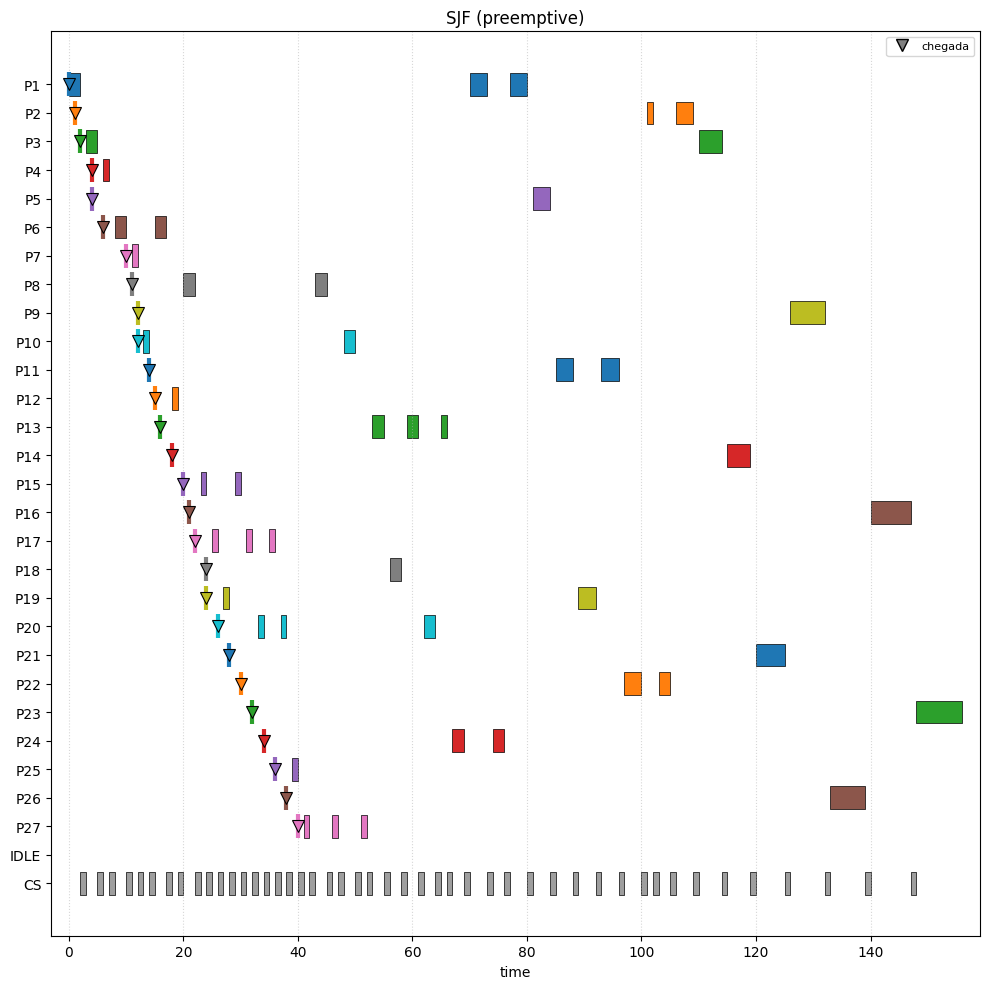

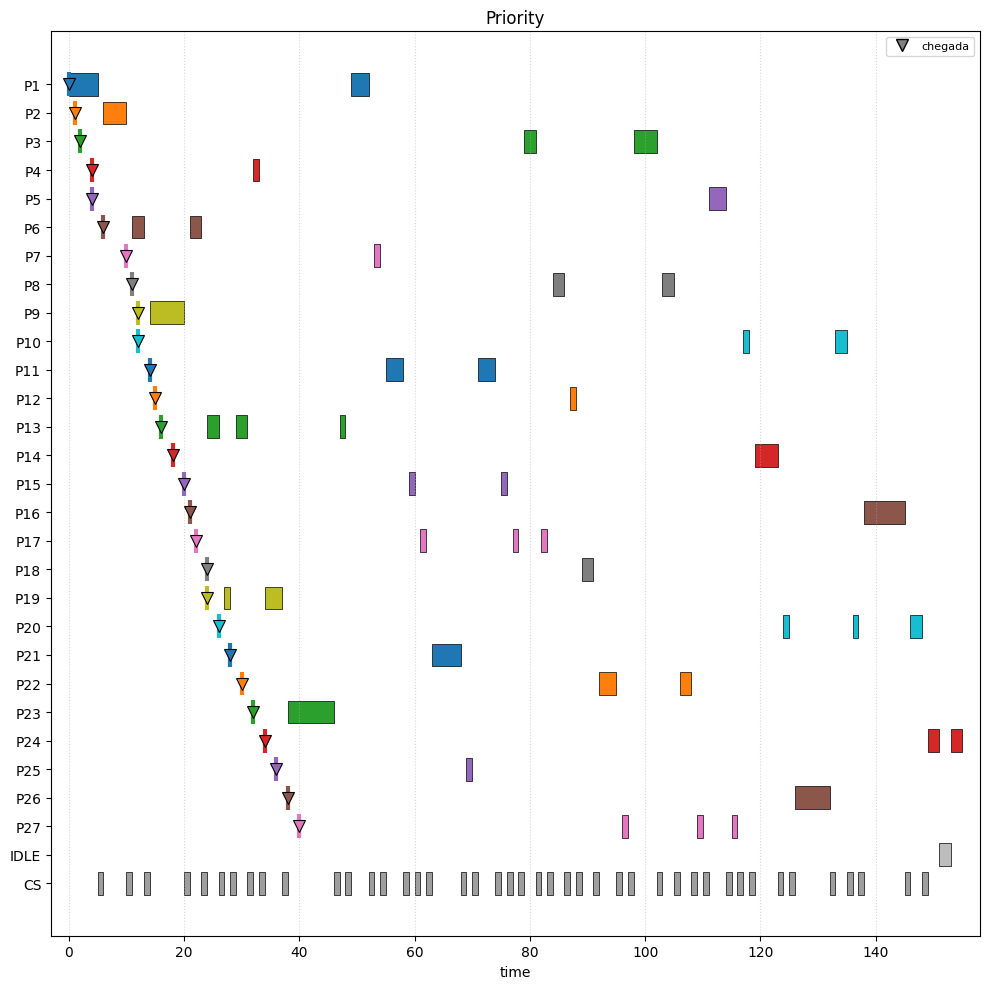

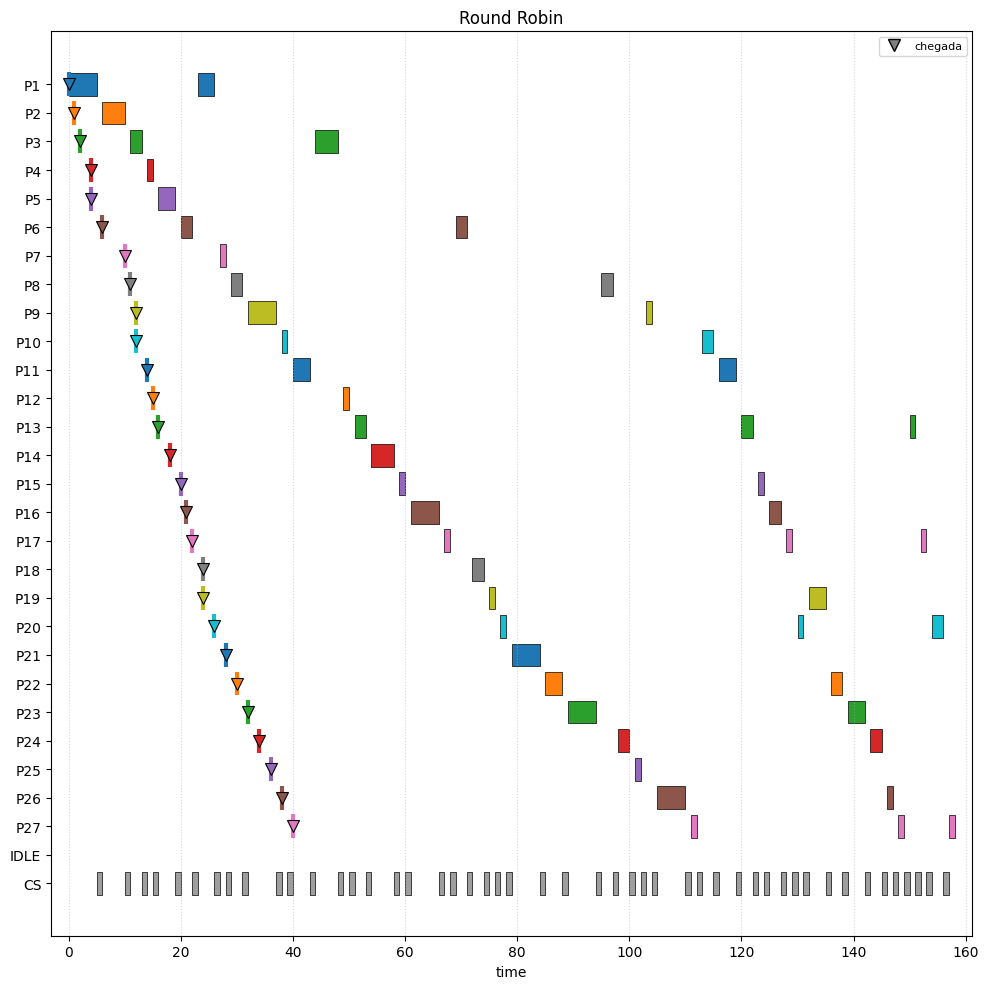

In [11]:
for result, gantt in zip(results, gantts):
    fig, ax = plt.subplots(figsize=(10, 10))
    plot_gantt(result, ax=ax, gantt=gantt)
    fig.tight_layout()
    plt.show()

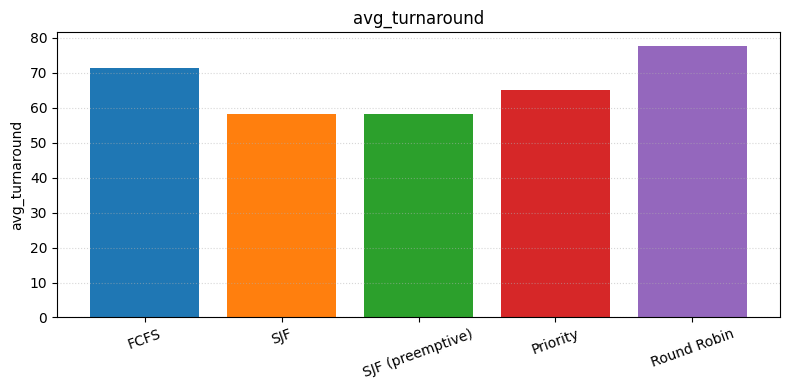

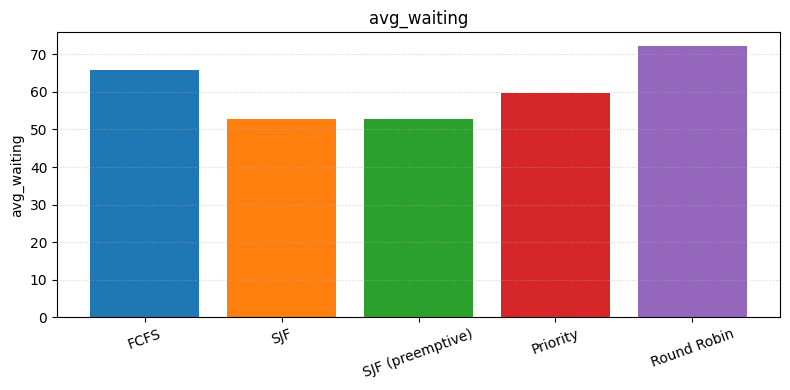

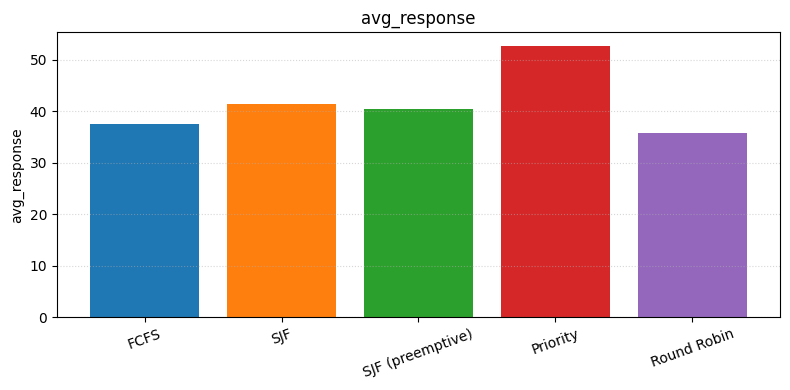

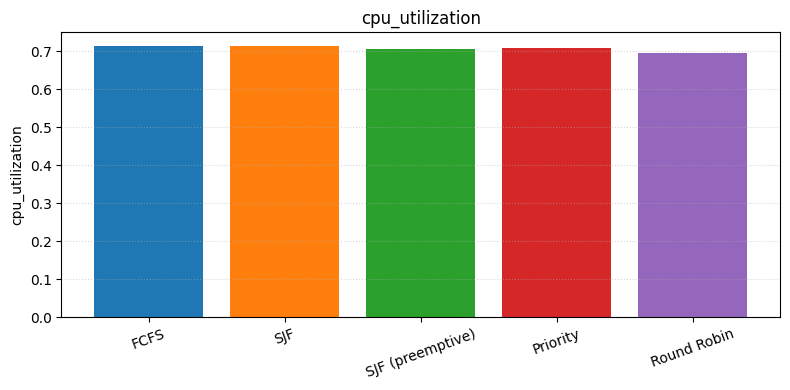

In [12]:
for metric in COMPARISON_METRICS:
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_metric_bars(reports, metric, ax=ax)
    fig.tight_layout()
    plt.show()